In [1]:
# Optional (run once): install extra package if missing

# !pip install caffemodel2pytorch
!pip install segmentation-models-pytorch -q
# !pip install albumentations -q
# !pip install opencv-python-headless -q

import os
import json
import zlib
import base64
import time
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

import albumentations as A
import segmentation_models_pytorch as smp
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

cv2.setNumThreads(0)
print('Torch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 93.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 

In [ ]:
# Paths and training config
DATA_ROOT = Path('/kaggle/input/datasets/[deepglobe dataset path]')
TRAIN_DIR = DATA_ROOT / 'train'
VAL_DIR = DATA_ROOT / 'val'
TEST_DIR = DATA_ROOT /'test'
TRAIN_IMG_DIR = TRAIN_DIR / 'img'
TRAIN_ANN_DIR = TRAIN_DIR / 'ann'
VAL_IMG_DIR = VAL_DIR / 'img'
VAL_ANN_DIR = VAL_DIR / 'ann'
TEST_IMG_DIR = TEST_DIR / 'img'
TEST_ANN_DIR = TEST_DIR / 'ann'

USE_RSICB_PRETRAINED = False

# Path to the converted .pth file for the ResNet-50 encoder pretrained on RSI-CB dataset
RSICB_ENCODER_CHECKPOINT = Path('/kaggle/input/datasets/rsi-cb256/resnet50_rsicb_encoder_from_caffe.pth')

CHECKPOINT_DIR = Path('/kaggle/working/checkpoints')
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
suffix = 'rsicb' if USE_RSICB_PRETRAINED else 'imagenet'
BEST_MODEL_PATH = CHECKPOINT_DIR / f'unet_resnet50_{suffix}_exp_best.pth'

NUM_CLASSES = 7
CLASS_NAMES = ['agriculture_land', 'barren_land', 'forest_land', 'rangeland', 'unknown', 'urban_land', 'water']
CLASS_ALIASES = {
    'agricultural_land': 'agriculture_land',
}

IGNORE_CLASS_NAME = 'unknown'
IGNORE_INDEX = CLASS_NAMES.index(IGNORE_CLASS_NAME)

IMAGE_SIZE = 1024
BATCH_SIZE = 2
NUM_WORKERS = 2
EPOCHS = 80
LR = 3e-4
WEIGHT_DECAY = 1e-4

SEED = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
print('DeepGlobe root exists:', DATA_ROOT.exists())
print('Train ann dir exists:', TRAIN_ANN_DIR.exists())
print('Val ann dir exists:', VAL_ANN_DIR.exists())
print('RSI-CB converted .pth exists:', RSICB_ENCODER_CHECKPOINT.exists())
print(f'Ignore class: {IGNORE_CLASS_NAME} (index={IGNORE_INDEX})')
print('Device:', DEVICE)


DeepGlobe root exists: True
Train ann dir exists: True
Val ann dir exists: True
RSI-CB converted .pth exists: True
Ignore class: unknown (index=4)
Device: cuda


In [3]:
def decode_bitmap_to_mask(bitmap_data):
    decoded = base64.b64decode(bitmap_data)
    decompressed = zlib.decompress(decoded)
    bitmap = np.frombuffer(decompressed, dtype=np.uint8)
    bitmap = cv2.imdecode(bitmap, cv2.IMREAD_UNCHANGED)
    if bitmap is None:
        return None
    if bitmap.ndim == 3:
        bitmap = bitmap[:, :, 0]
    return bitmap

def resolve_image_path(img_dir, ann_name_no_json):
    direct = img_dir / ann_name_no_json
    if direct.exists():
        return direct

    candidates = [
        img_dir / f"{ann_name_no_json}.jpg",
        img_dir / f"{ann_name_no_json}.png",
        img_dir / f"{ann_name_no_json}.jpeg",
    ]
    for p in candidates:
        if p.exists():
            return p
    return None

class DeepGlobeJsonAnnDataset(Dataset):
    def __init__(self, image_dir, ann_dir, class_names, class_aliases=None, image_size=256, augment=False):
        self.image_dir = Path(image_dir)
        self.ann_dir = Path(ann_dir)
        self.image_size = image_size
        self.class_aliases = class_aliases or {}
        self.class_to_idx = {name: i for i, name in enumerate(class_names)}

        ann_files = sorted(self.ann_dir.glob('*.json'))
        self.samples = []
        for ann_path in ann_files:
            ann_name_no_json = ann_path.name[:-5]
            img_path = resolve_image_path(self.image_dir, ann_name_no_json)
            if img_path is not None:
                self.samples.append((img_path, ann_path))

        if augment:
            self.transform = A.Compose([
                A.Resize(image_size, image_size),
            
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
                A.RandomRotate90(p=0.5),
                
                A.RandomBrightnessContrast(p=0.5),
                A.HueSaturationValue(p=0.3),
            
                A.Normalize(
                    mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)
                ),
            ])
        else:
            self.transform = A.Compose([
                A.Resize(image_size, image_size),
                A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ])

    def __len__(self):
        return len(self.samples)

    def _normalize_class_name(self, class_title):
        if class_title in self.class_to_idx:
            return class_title
        return self.class_aliases.get(class_title, class_title)

    def __getitem__(self, idx):
        img_path, ann_path = self.samples[idx]

        image = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w = image.shape[:2]
        mask = np.full((h, w), self.class_to_idx['unknown'], dtype=np.uint8)

        with open(ann_path, 'r', encoding='utf-8') as f:
            ann_json = json.load(f)

        for obj in ann_json.get('objects', []):
            raw_name = obj.get('classTitle', 'unknown')
            class_name = self._normalize_class_name(raw_name)
            class_id = self.class_to_idx.get(class_name, self.class_to_idx['unknown'])
            geom_type = obj.get('geometryType', '')

            if geom_type == 'bitmap':
                bitmap_meta = obj.get('bitmap', {})
                bitmap_data = bitmap_meta.get('data')
                origin = bitmap_meta.get('origin', [0, 0])
                if bitmap_data is None:
                    continue

                bm = decode_bitmap_to_mask(bitmap_data)
                if bm is None:
                    continue

                x0, y0 = int(origin[0]), int(origin[1])
                y1 = min(y0 + bm.shape[0], h)
                x1 = min(x0 + bm.shape[1], w)
                if y0 >= y1 or x0 >= x1:
                    continue

                bm_crop = bm[: y1 - y0, : x1 - x0]
                region = mask[y0:y1, x0:x1]
                region[bm_crop > 0] = class_id
                mask[y0:y1, x0:x1] = region

            elif geom_type == 'polygon':
                points = obj.get('points', {}).get('exterior', [])
                if len(points) >= 3:
                    pts = np.array(points, dtype=np.int32)
                    cv2.fillPoly(mask, [pts], color=class_id)

        transformed = self.transform(image=image, mask=mask)
        image = transformed['image']
        mask = transformed['mask']

        image = torch.from_numpy(image).permute(2, 0, 1).float()
        mask = torch.from_numpy(mask).long()

        return image, mask

train_dataset = DeepGlobeJsonAnnDataset(
    TRAIN_IMG_DIR,
    TRAIN_ANN_DIR,
    class_names=CLASS_NAMES,
    class_aliases=CLASS_ALIASES,
    image_size=IMAGE_SIZE,
    augment=True,
)

val_dataset = DeepGlobeJsonAnnDataset(
    VAL_IMG_DIR,
    VAL_ANN_DIR,
    class_names=CLASS_NAMES,
    class_aliases=CLASS_ALIASES,
    image_size=IMAGE_SIZE,
    augment=False,
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

print('Train samples:', len(train_dataset))
print('Val samples:', len(val_dataset))

Train samples: 562
Val samples: 168


In [4]:
# ==================== COMPUTE CLASS WEIGHTS FOR TN2 ====================

print("Tính class weights từ thống kê pixel toàn bộ tập train...")

# Thống kê pixel đã tính từ train set gốc
class_counts = np.array([
    161176257,  # agriculture_land
    22563586,   # barren_land
    36179699,   # forest_land
    25701974,   # rangeland
    522316,     # unknown
    28750769,   # urban_land
    8810743     # water
], dtype=np.float64)

# Không dùng unknown để train
class_counts[IGNORE_INDEX] = 0

class_weights = np.zeros(NUM_CLASSES, dtype=np.float32)
valid_classes = [c for c in range(NUM_CLASSES) if c != IGNORE_INDEX]

# Inverse sqrt frequency
# Lớp càng ít pixel thì weight càng cao
for c in valid_classes:
    class_weights[c] = 1.0 / np.sqrt(class_counts[c] + 1e-8)

# Chuẩn hóa để mean weight của các class hợp lệ = 1
mean_w = class_weights[valid_classes].mean()
class_weights[valid_classes] = class_weights[valid_classes] / (mean_w + 1e-8)

# Ignore unknown
class_weights[IGNORE_INDEX] = 0.0

print("\nKết quả Class Weights:")
for i, (name, count, weight) in enumerate(zip(CLASS_NAMES, class_counts, class_weights)):
    print(f"  Lớp {i} ({name:20s}) | pixels: {int(count):12d} | weight: {weight:.3f}")

class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE
)


Tính class weights từ thống kê pixel toàn bộ tập train...

Kết quả Class Weights:
  Lớp 0 (agriculture_land    ) | pixels:    161176257 | weight: 0.402
  Lớp 1 (barren_land         ) | pixels:     22563586 | weight: 1.074
  Lớp 2 (forest_land         ) | pixels:     36179699 | weight: 0.848
  Lớp 3 (rangeland           ) | pixels:     25701974 | weight: 1.006
  Lớp 4 (unknown             ) | pixels:            0 | weight: 0.000
  Lớp 5 (urban_land          ) | pixels:     28750769 | weight: 0.951
  Lớp 6 (water               ) | pixels:      8810743 | weight: 1.718


In [ ]:
# Loss and metrics (ignore unknown class)

class CombinedLoss(nn.Module):
    def __init__(self, class_weights=None):
        super().__init__()
        self.dice = smp.losses.DiceLoss(mode='multiclass', ignore_index=IGNORE_INDEX)
        self.ce = nn.CrossEntropyLoss(weight=class_weights, ignore_index=IGNORE_INDEX)
        self.focal = smp.losses.FocalLoss(mode='multiclass', ignore_index=IGNORE_INDEX, gamma=2.0)

    def forward(self, logits, targets):
        return 0.3 * self.ce(logits, targets) \
             + 0.5 * self.dice(logits, targets) \
             + 0.2 * self.focal(logits, targets)
        
def tta_predict(model, images):
    """Dự đoán trung bình đa hướng (Original, Horizontal, Vertical Flip) tăng cường mIoU biên"""
    model.eval()
    logits_list = []
    
    with torch.no_grad():
        with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
            # 1. Ảnh gốc
            logits_list.append(model(images))
            
            # 2. Lật ngang
            hflip_images = torch.flip(images, dims=[3])
            hflip_logits = model(hflip_images)
            logits_list.append(torch.flip(hflip_logits, dims=[3]))
            
            # 3. Lật dọc
            vflip_images = torch.flip(images, dims=[2])
            vflip_logits = model(vflip_images)
            logits_list.append(torch.flip(vflip_logits, dims=[2]))
            
    return torch.stack(logits_list, dim=0).mean(dim=0).float()

print('Loss & TTA Helpers Defined.')
class MeanIoU:
    def __init__(self, num_classes, ignore_index=None):
        self.num_classes = num_classes
        self.ignore_index = ignore_index
        self.confusion_matrix = np.zeros((num_classes, num_classes))

    def update(self, preds, targets):
        preds = preds.view(-1).cpu().numpy()
        targets = targets.view(-1).cpu().numpy()

        if self.ignore_index is not None:
            mask = targets != self.ignore_index
            preds = preds[mask]
            targets = targets[mask]

        cm = np.bincount(
            self.num_classes * targets + preds,
            minlength=self.num_classes ** 2
        ).reshape(self.num_classes, self.num_classes)

        self.confusion_matrix += cm

    def compute(self):
        ious = []

        for cls in range(self.num_classes):
            if cls == self.ignore_index:
                continue

            tp = self.confusion_matrix[cls, cls]
            fp = self.confusion_matrix[:, cls].sum() - tp
            fn = self.confusion_matrix[cls, :].sum() - tp

            union = tp + fp + fn

            if union > 0:
                ious.append(tp / union)

        return np.mean(ious)

def compute_per_class_iou(metric, class_names, ignore_index=None):
    cm = metric.confusion_matrix
    for cls, name in enumerate(class_names):
        if cls == ignore_index:
            continue

        tp = cm[cls, cls]
        fp = cm[:, cls].sum() - tp
        fn = cm[cls, :].sum() - tp
        union = tp + fp + fn

        iou = tp / union if union > 0 else 0.0
        print(f"{cls} - {name:20s}: IoU = {iou:.4f}")
        
print('Done')

Loss & TTA Helpers Defined.
Done


In [6]:
def load_rsicb_encoder_checkpoint(unet_model, checkpoint_path):
    checkpoint_path = Path(checkpoint_path)
    if not checkpoint_path.exists():
        raise FileNotFoundError(
            f'RSI-CB encoder checkpoint not found: {checkpoint_path}. '
            'Exp2 requires RSI-CB pretrained encoder.'
        )

    # Load checkpoint
    checkpoint = torch.load(str(checkpoint_path), map_location='cpu', weights_only=False)
    
    # Kiểm tra các keys phổ biến trong checkpoint (state_dict hoặc model_state_dict)
    if isinstance(checkpoint, dict):
        state_dict = checkpoint.get('state_dict', checkpoint.get('model_state_dict', checkpoint))
    else:
        state_dict = checkpoint

    # Xử lý prefix nếu checkpoint lưu cả model thay vì chỉ encoder
    if any(key.startswith('encoder.') for key in state_dict.keys()):
        encoder_state = {
            key.replace('encoder.', '', 1): value
            for key, value in state_dict.items()
            if key.startswith('encoder.')
        }
    elif any(key.startswith('model.encoder.') for key in state_dict.keys()):
        encoder_state = {
            key.replace('model.encoder.', '', 1): value
            for key, value in state_dict.items()
            if key.startswith('model.encoder.')
        }
    else:
        encoder_state = state_dict

    # Sửa lỗi Unpack bằng cách kiểm tra kết quả trả về
    result = unet_model.encoder.load_state_dict(encoder_state, strict=False)
    
    print(f'Loaded RSI-CB encoder checkpoint from: {checkpoint_path}')
    
    # Chỉ in missing/unexpected keys nếu hàm load_state_dict trả về chúng (PyTorch version >= 1.1)
    if result is not None:
        missing, unexpected = result
        print(f'Missing keys: {len(missing)} | Unexpected keys: {len(unexpected)}')
    else:
        print('Successfully loaded state_dict (Old PyTorch version detected).')
        
    return True

print('Defined load rsicb')

Defined load rsicb


In [7]:
# Build U-Net with ResNet50 encoder (no ImageNet init for strict Exp2 RSI-CB transfer)
model = smp.Unet(
    encoder_name='efficientnet-b5',
    encoder_weights='imagenet',
    in_channels=3,
    classes=NUM_CLASSES,
    activation=None,
)

# Load RSI-CB pretrained encoder checkpoint (.pth)
if USE_RSICB_PRETRAINED:
    load_rsicb_encoder_checkpoint(model, RSICB_ENCODER_CHECKPOINT)
    print("-> Training model from RSI-CB")
else:
    print("-> Training model from ImageNet")

model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params: {total_params:,}')
print(f'Trainable params: {trainable_params:,}')

print('Done')

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/122M [00:00<?, ?B/s]

-> Training model from ImageNet
Total params: 31,216,871
Trainable params: 31,216,871
Done


In [8]:
# Optimizer / scheduler / criterion
criterion = CombinedLoss(class_weights=class_weights_tensor)

optimizer = optim.AdamW([
    {'params': model.encoder.parameters(), 'lr': LR * 0.3},
    {'params': model.decoder.parameters(), 'lr': LR},
    {'params': model.segmentation_head.parameters(), 'lr': LR},
], weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-6
)

scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())

print('Optimizer and Scaler configured.')

Optimizer and Scaler configured.


In [9]:
def dice_from_iou(miou):
    return (2 * miou) / (1 + miou + 1e-8)


def train_one_epoch(model, loader, optimizer, criterion, device, scaler=None):
    model.train()
    total_loss = 0.0
    metric = MeanIoU(num_classes=NUM_CLASSES, ignore_index=IGNORE_INDEX)

    for images, masks in tqdm(loader, desc='Train', leave=False):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
            logits = model(images)
            loss = criterion(logits, masks)

        if scaler is not None and torch.cuda.is_available():
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        preds = logits.argmax(dim=1)
        metric.update(preds.detach(), masks.detach())

        total_loss += loss.item() * images.size(0)

    train_loss = total_loss / len(loader.dataset)
    train_miou = metric.compute()
    train_dice = dice_from_iou(train_miou)

    return train_loss, train_miou, train_dice


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device, num_classes=7, ignore_index=None):
    model.eval()
    total_loss = 0.0
    metric = MeanIoU(num_classes=num_classes, ignore_index=ignore_index)

    for images, masks in tqdm(loader, desc='Valid', leave=False):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        logits = tta_predict(model, images)

        with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
            loss = criterion(logits, masks)

        preds = logits.argmax(dim=1)

        total_loss += loss.item() * images.size(0)
        metric.update(preds, masks)

    val_loss = total_loss / len(loader.dataset)
    val_miou = metric.compute()
    val_dice = dice_from_iou(val_miou)

    return val_loss, val_miou, val_dice, metric

print('Done')

Done


In [10]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_miou": [],
    "val_miou": [],
    "train_dice": [],
    "val_dice": [],
    "lr": [],
}
best_miou = -1.0
best_val_metric = None
start_time = time.time()
patience = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_miou, train_dice = train_one_epoch(
        model, train_loader, optimizer, criterion, DEVICE, scaler=scaler
    )

    val_loss, val_miou, val_dice, val_metric = validate_one_epoch(
        model,
        val_loader,
        criterion,
        DEVICE,
        num_classes=NUM_CLASSES,
        ignore_index=IGNORE_INDEX,
    )

    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_miou'].append(train_miou)
    history['val_miou'].append(val_miou)
    history['train_dice'].append(train_dice)
    history['val_dice'].append(val_dice)
    history['lr'].append(current_lr)

    print(
        f'Epoch {epoch:03d}/{EPOCHS} | '
        f'train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | '
        f'train_mIoU={train_miou:.4f} | val_mIoU={val_miou:.4f} | '
        f'train_dice={train_dice:.4f} | val_dice={val_dice:.4f} | '
        f'lr={current_lr:.2e}'
    )

    if val_miou > best_miou:
        best_miou = val_miou
        best_val_metric = val_metric
        patience = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_miou': best_miou,
            'config': {
                'encoder_name': 'resnet50',
                'pretrain_source': 'RSI-CB256' if USE_RSICB_PRETRAINED else 'Scratch (Random)',
                'ignore_class': IGNORE_CLASS_NAME,
                'ignore_index': IGNORE_INDEX,
                'image_size': IMAGE_SIZE,
                'batch_size': BATCH_SIZE,
                'epochs': EPOCHS,
            },
        }, str(BEST_MODEL_PATH))
        print(f'  -> Saved best model: {BEST_MODEL_PATH}')
    else:
        patience += 1
        print(f' No improvement({patience}/15)')
        if (patience >= 20):
            print("Early stopping triggered")
            break

elapsed = time.time() - start_time
print(f'Training done. Best mIoU={best_miou:.4f}. Time={elapsed/60:.1f} min')

compute_per_class_iou(
    best_val_metric,
    CLASS_NAMES,
    ignore_index=IGNORE_INDEX
)

Train:   0%|          | 0/281 [00:00<?, ?it/s]

Valid:   0%|          | 0/84 [00:00<?, ?it/s]

Epoch 001/80 | train_loss=0.8924 | val_loss=0.6139 | train_mIoU=0.1978 | val_mIoU=0.3871 | train_dice=0.3302 | val_dice=0.5581 | lr=9.00e-05
  -> Saved best model: /kaggle/working/checkpoints/unet_resnet50_imagenet_exp_best.pth


Train:   0%|          | 0/281 [00:00<?, ?it/s]

Valid:   0%|          | 0/84 [00:00<?, ?it/s]

...

Valid:   0%|          | 0/84 [00:00<?, ?it/s]

Epoch 075/80 | train_loss=0.1715 | val_loss=0.3207 | train_mIoU=0.8508 | val_mIoU=0.7259 | train_dice=0.9194 | val_dice=0.8412 | lr=1.86e-06
 No improvement(19/15)


Train:   0%|          | 0/281 [00:00<?, ?it/s]

Valid:   0%|          | 0/84 [00:00<?, ?it/s]

Epoch 076/80 | train_loss=0.1743 | val_loss=0.3236 | train_mIoU=0.8491 | val_mIoU=0.7258 | train_dice=0.9184 | val_dice=0.8411 | lr=1.55e-06
 No improvement(20/15)
Early stopping triggered
Training done. Best mIoU=0.7288. Time=301.6 min
0 - agriculture_land    : IoU = 0.8874
1 - barren_land         : IoU = 0.6421
2 - forest_land         : IoU = 0.7998
3 - rangeland           : IoU = 0.4173
5 - urban_land          : IoU = 0.7885
6 - water               : IoU = 0.8380


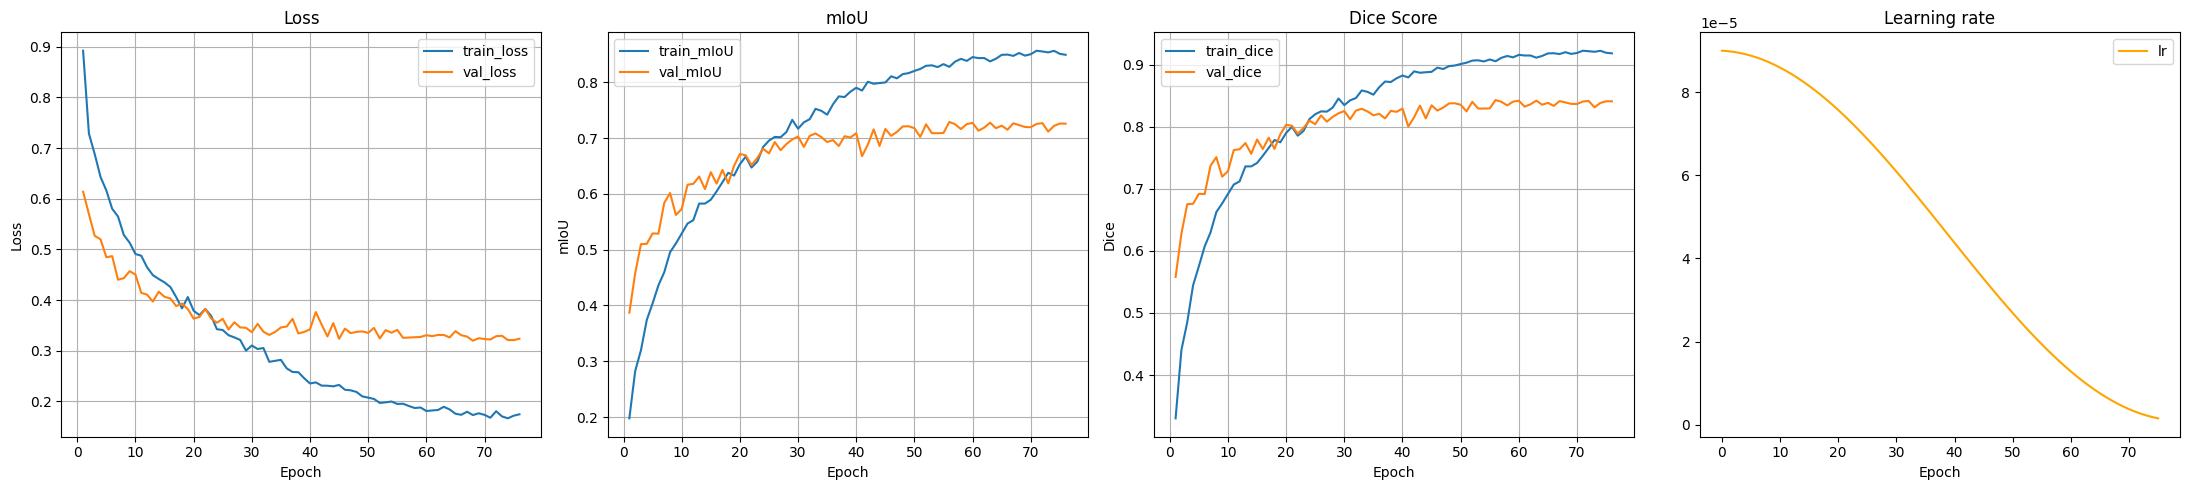

In [11]:
SAVE_DIR = '/kaggle/working/plots'
os.makedirs(SAVE_DIR, exist_ok=True)

epochs = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(22, 5))

plt.subplot(1, 4, 1)
plt.plot(epochs, history['train_loss'], label='train_loss')
plt.plot(epochs, history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 4, 2)
plt.plot(epochs, history['train_miou'], label='train_mIoU')
plt.plot(epochs, history['val_miou'], label='val_mIoU')
plt.title('mIoU')
plt.xlabel('Epoch')
plt.ylabel('mIoU')
plt.legend()
plt.grid(True)

plt.subplot(1, 4, 3)
plt.plot(epochs, history['train_dice'], label='train_dice')
plt.plot(epochs, history['val_dice'], label='val_dice')
plt.title('Dice Score')
plt.xlabel('Epoch')
plt.ylabel('Dice')
plt.legend()
plt.grid(True)

plt.subplot(1, 4, 4)
plt.plot(history['lr'], label='lr', color='orange')
plt.title('Learning rate')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_curves.png'), dpi=300)
plt.show()

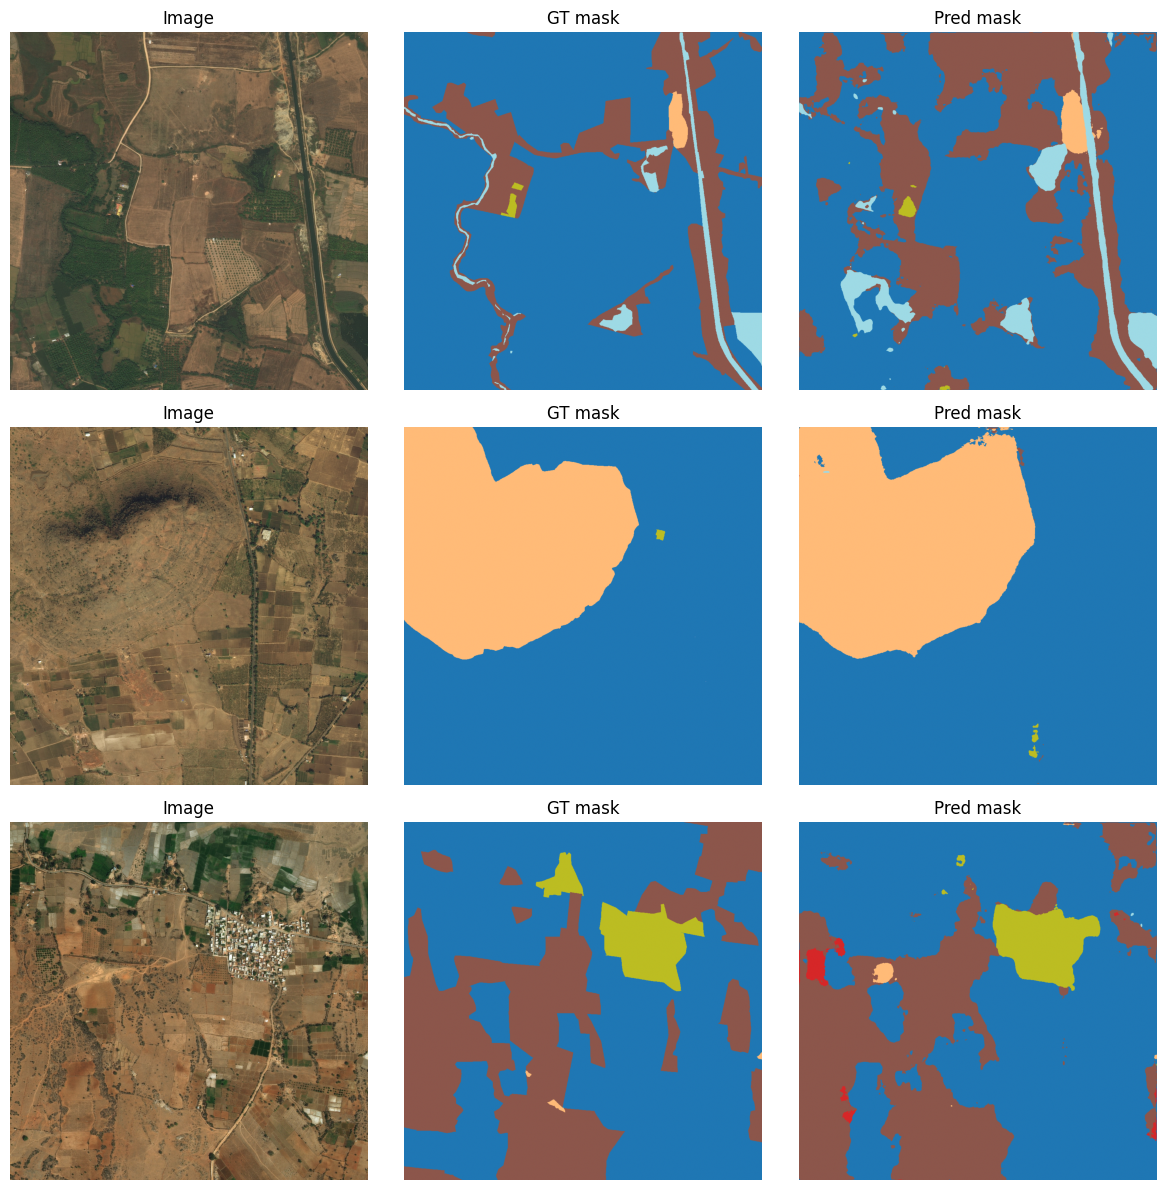

In [12]:
# Quick inference visualization
@torch.no_grad()
def visualize_predictions(model, dataset, device, n_samples=3):
    model.eval()
    idxs = np.random.choice(len(dataset), size=min(n_samples, len(dataset)), replace=False)

    plt.figure(figsize=(12, 4 * len(idxs)))

    for i, idx in enumerate(idxs):
        image, mask = dataset[idx]
        logits = model(image.unsqueeze(0).to(device))
        pred = logits.argmax(dim=1).squeeze(0).cpu().numpy()

        img_np = image.permute(1, 2, 0).cpu().numpy()
        img_np = (img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]))
        img_np = np.clip(img_np, 0, 1)

        plt.subplot(len(idxs), 3, i * 3 + 1)
        plt.imshow(img_np)
        plt.title('Image')
        plt.axis('off')

        plt.subplot(len(idxs), 3, i * 3 + 2)
        plt.imshow(mask.cpu().numpy(), vmin=0, vmax=NUM_CLASSES - 1, cmap='tab20')
        plt.title('GT mask')
        plt.axis('off')

        plt.subplot(len(idxs), 3, i * 3 + 3)
        plt.imshow(pred, vmin=0, vmax=NUM_CLASSES - 1, cmap='tab20')
        plt.title('Pred mask')
        plt.axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'visualization_grid.png'), dpi=300)
    plt.show()

visualize_predictions(model, val_dataset, DEVICE, n_samples=3)

In [13]:
# ==================== ĐỊNH NGHĨA TEST DATASET & DATALOADER ====================
print("Loading Test Dataset...")

test_dataset = DeepGlobeJsonAnnDataset(
    TEST_IMG_DIR,
    TEST_ANN_DIR,
    class_names=CLASS_NAMES,
    class_aliases=CLASS_ALIASES,
    image_size=IMAGE_SIZE,
    augment=False, # Không augmentation khi test
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=NUM_WORKERS, 
    pin_memory=torch.cuda.is_available()
)

print(f'Test samples: {len(test_dataset)}')

Loading Test Dataset...
Test samples: 73


Loading best checkpoint from: /kaggle/working/checkpoints/unet_resnet50_imagenet_exp_best.pth


Evaluating Test Set:   0%|          | 0/37 [00:00<?, ?it/s]

(7, 7)

Confusion Matrix - Pixel Count:
                  agriculture_land  barren_land  forest_land  rangeland  \
agriculture_land        37088538.0     500767.0     565184.0  1409723.0   
barren_land               505713.0    5241513.0     262775.0  1064655.0   
forest_land               380816.0     132730.0    8020869.0   766232.0   
rangeland                1571563.0     115531.0     566142.0  3908493.0   
urban_land                337526.0     323814.0      72256.0   483144.0   
water                     106070.0      23962.0      48428.0   107285.0   

                  urban_land      water  
agriculture_land    370155.0   145477.0  
barren_land         361637.0   112869.0  
forest_land          36334.0    48721.0  
rangeland           494475.0    94096.0  
urban_land         8576146.0    10167.0  
water                13102.0  2677231.0  

Normalized Confusion Matrix:
                  agriculture_land  barren_land  forest_land  rangeland  \
agriculture_land            0.9254 

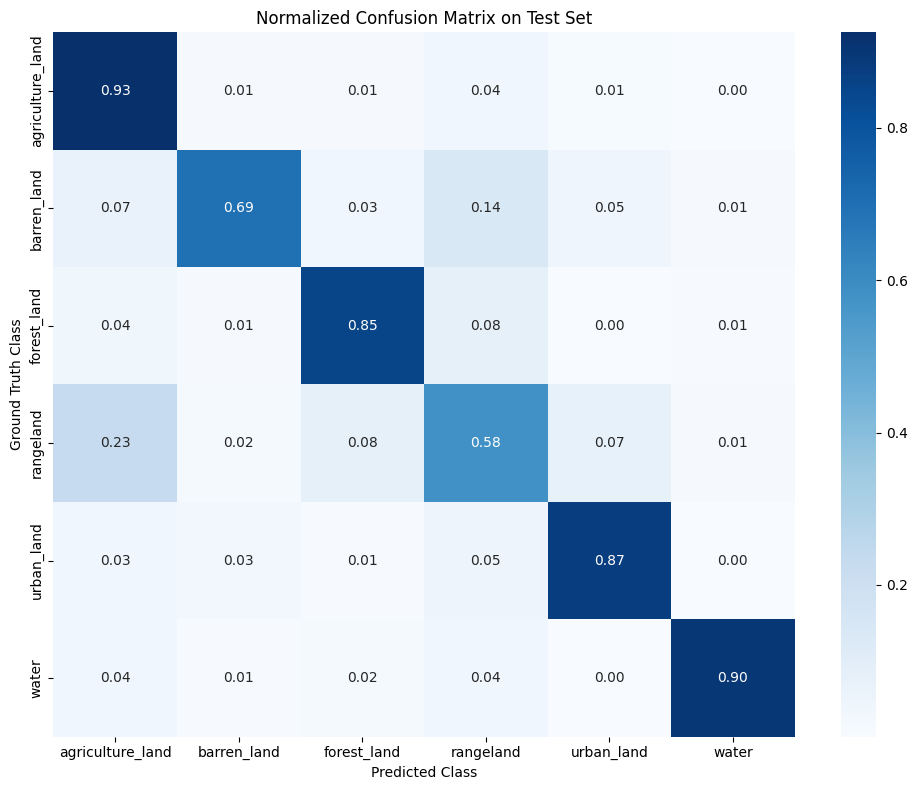


               KẾT QUẢ TRÊN TẬP TEST CHÍNH THỨC
Mã lớp     | Tên lớp Đất               | IoU score      
------------------------------------------------------------
0          | agriculture_land          | 0.8629
1          | barren_land               | 0.6062
2          | forest_land               | 0.7358
3          | rangeland                 | 0.3694
5          | urban_land                | 0.7741
6          | water                     | 0.7903
------------------------------------------------------------
👉 Điểm TRUNG BÌNH TOÀN CỤC (mIoU trên tập Test): 0.6898
👉 Điểm Dice TRUNG BÌNH trên tập Test: 0.8040


In [14]:
# ==================== ĐÁNH GIÁ TRÊN TẬP KIỂM THỬ (TEST SET) ====================
print(f"Loading best checkpoint from: {BEST_MODEL_PATH}")

# 1. Nạp lại trọng số tốt nhất đã đạt được trong quá trình Train
checkpoint = torch.load(str(BEST_MODEL_PATH), map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])

# 2. Tiến hành tính toán ma trận nhầm lẫn (Confusion Matrix) trên tập Test
model.eval()
test_metric = MeanIoU(num_classes=NUM_CLASSES, ignore_index=IGNORE_INDEX)

with torch.no_grad():
    for images, masks in tqdm(test_loader, desc='Evaluating Test Set'):
        images = images.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)

        # Sử dụng hàm dự đoán đa hướng TTA đã cấu hình ở bước trước để tối ưu hiệu năng
        logits = tta_predict(model, images)
        preds = logits.argmax(dim=1)

        # Cập nhật dữ liệu vào ma trận để tính IoU từng lớp
        test_metric.update(preds, masks)

# 3. Tính toán số liệu báo cáo Đồ án
test_miou = test_metric.compute()

# ==================== TEST DICE SCORE ====================
cm_for_dice = test_metric.confusion_matrix
if isinstance(cm_for_dice, torch.Tensor):
    cm_for_dice = cm_for_dice.cpu().numpy()
dice_scores = []
for cls_idx in range(NUM_CLASSES):
    if cls_idx == IGNORE_INDEX:
        continue
    tp = cm_for_dice[cls_idx, cls_idx]
    fp = cm_for_dice[:, cls_idx].sum() - tp
    fn = cm_for_dice[cls_idx, :].sum() - tp
    dice = (2 * tp) / (2 * tp + fp + fn + 1e-8)
    dice_scores.append(dice)
test_dice = np.nanmean(dice_scores)
# ==================== CONFUSION MATRIX ====================
cm = test_metric.confusion_matrix
if isinstance(cm, torch.Tensor):
    cm = cm.cpu().numpy()
print(cm.shape)
# Nếu muốn bỏ unknown khỏi bảng hiển thị
valid_indices = [i for i in range(NUM_CLASSES) if i != IGNORE_INDEX]
valid_class_names = [CLASS_NAMES[i] for i in valid_indices]
cm_valid = cm[np.ix_(valid_indices, valid_indices)]
# Confusion matrix dạng số pixel
df_cm = pd.DataFrame(
    cm_valid,
    index=valid_class_names,
    columns=valid_class_names
)
print("\nConfusion Matrix - Pixel Count:")
print(df_cm)
# Normalize theo từng hàng: mỗi hàng Ground Truth cộng lại = 1
cm_norm = cm_valid.astype(np.float64)
cm_norm = cm_norm / (cm_norm.sum(axis=1, keepdims=True) + 1e-8)
df_cm_norm = pd.DataFrame(
    cm_norm,
    index=valid_class_names,
    columns=valid_class_names
)
print("\nNormalized Confusion Matrix:")
print(df_cm_norm.round(4))
plt.figure(figsize=(10, 8))
sns.heatmap(
    df_cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)
plt.xlabel("Predicted Class")
plt.ylabel("Ground Truth Class")
plt.title("Normalized Confusion Matrix on Test Set")
plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"               KẾT QUẢ TRÊN TẬP TEST CHÍNH THỨC")
print(f"{'='*60}")
print(f"{'Mã lớp':<10} | {'Tên lớp Đất':<25} | {'IoU score':<15}")
print(f"{'-'*60}")

# In chi tiết từng lớp để vẽ biểu đồ cột trong luận văn
for cls_idx, name in enumerate(CLASS_NAMES):
    if cls_idx == IGNORE_INDEX:
        continue
    
    tp = test_metric.confusion_matrix[cls_idx, cls_idx]
    fp = test_metric.confusion_matrix[:, cls_idx].sum() - tp
    fn = test_metric.confusion_matrix[cls_idx, :].sum() - tp
    union = tp + fp + fn
    
    class_iou = tp / union if union > 0 else float('nan')
    print(f"{cls_idx:<10} | {name:<25} | {class_iou:.4f}")

print(f"{'-'*60}")
print(f"👉 Điểm TRUNG BÌNH TOÀN CỤC (mIoU trên tập Test): {test_miou:.4f}")
print(f"👉 Điểm Dice TRUNG BÌNH trên tập Test: {test_dice:.4f}")
print(f"{'='*60}")